In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.metrics import classification_report,roc_auc_score,roc_curve
from sklearn.model_selection import train_test_split

In [2]:
np.random.seed(42)

# Generating imbalanced dataset
n_samples_1 = 25  # Number of samples in class 1
n_samples_2 = 375  # Number of samples in class 2
centers = [(0, 0), (2, 2)]  # Centers of each cluster
cluster_std = [1.5, 1.5]  # Standard deviation of each cluster
X, y = make_blobs(n_samples=[n_samples_1, n_samples_2],
                centers=centers,
                cluster_std=cluster_std,
                random_state=0)

In [6]:
print(X.shape)
print(y.shape)

(400, 2)
(400,)


In [12]:
centers

[(0, 0), (2, 2)]

C:\Users\sathe\AppData\Local\Temp\ipykernel_20756\2975822302.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


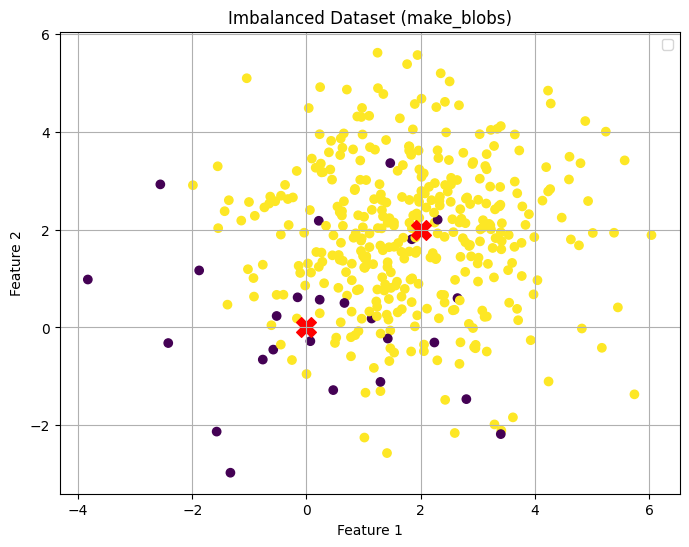

In [ ]:
# Plotting
centers = np.array(centers) 
plt.figure(figsize=(8,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='viridis')
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, marker='X')
plt.title("Imbalanced Dataset (make_blobs)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()






In [3]:
# without treating imbalance
from sklearn.linear_model import LogisticRegression
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)
lr = LogisticRegression()
lr.fit(X_train,y_train)
y_pred = lr.predict(X_test)
y_prob = lr.predict_proba(X_test)[:,1] # probability of class 1 for each sample
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.29      0.44         7
           1       0.96      1.00      0.98       113

    accuracy                           0.96       120
   macro avg       0.98      0.64      0.71       120
weighted avg       0.96      0.96      0.95       120



In [19]:
# here recall is 0.29 . i.e for 100 data points, just 29 minority point are  correclty classified, 71 are misclasified

In [21]:
print("ROC AUC Score:", roc_auc_score(y_test, y_prob))

ROC AUC Score: 0.9557522123893806


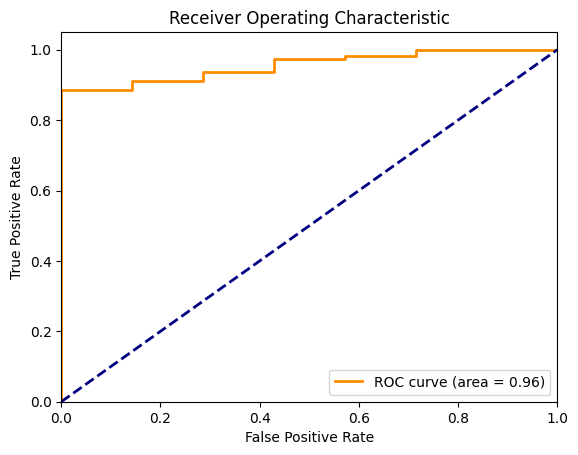

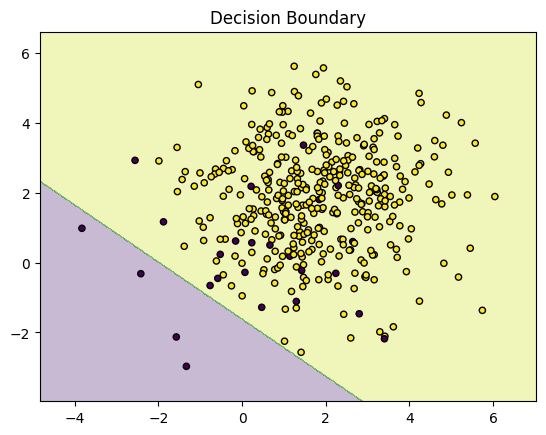

In [25]:
# Plotting ROC AUC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc_score(y_test, y_prob))
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# Function to plot decision boundaries
def plot_decision_boundaries(X, y, model):
    plot_step = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                         np.arange(y_min, y_max, plot_step))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', s=20)
    plt.title("Decision Boundary")
    plt.show()

# Plot decision boundary
plot_decision_boundaries(X, y, lr)

Undersampling effects
Before sampling : 1    262
0     18
Name: count, dtype: int64
After sampling 0    18
1    18
Name: count, dtype: int64


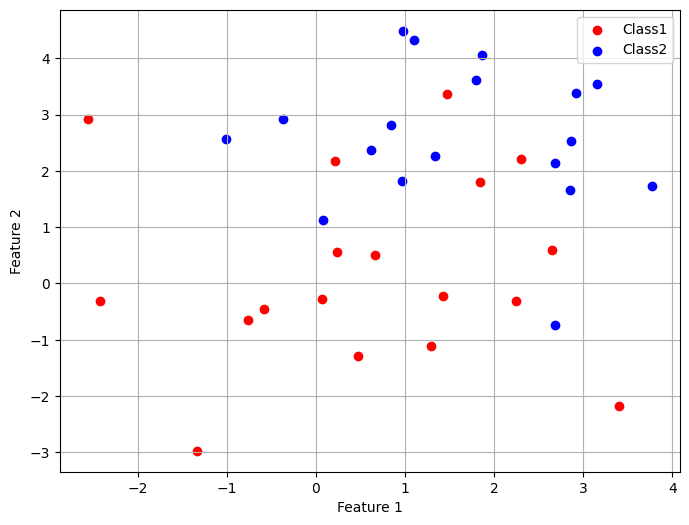

In [4]:
# Random Undersampling

from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)

X_resampled,y_resampled = rus.fit_resample(X_train,y_train)
print("Undersampling effects")
print(f"Before sampling : {pd.Series(y_train).value_counts()}")
print(f"After sampling",pd.Series(y_resampled).value_counts())
plt.figure(figsize=(8,6))
plt.scatter(X_resampled[y_resampled==0][:,0],X_resampled[y_resampled==0][:,1],color = 'red',label='Class1')
plt.scatter(X_resampled[y_resampled==1][:,0],X_resampled[y_resampled==1][:,1],color = 'blue',label='Class2')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()




In [5]:
lr.fit(X_resampled, y_resampled)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [6]:
y_pred_rus = lr.predict(X_test)
y_prob_rus =lr.predict_proba(X_test)[:,1]
# Print classification report for resampled data
print("Classification Report (With Under Sampling):")
print(classification_report(y_test, y_pred_rus))

# Print ROC AUC Score for resampled data
print("ROC AUC Score (With Under Sampling):", roc_auc_score(y_test, y_prob_rus))



Classification Report (With Under Sampling):
              precision    recall  f1-score   support

           0       0.13      1.00      0.23         7
           1       1.00      0.59      0.74       113

    accuracy                           0.62       120
   macro avg       0.57      0.80      0.49       120
weighted avg       0.95      0.62      0.71       120

ROC AUC Score (With Under Sampling): 0.9469026548672567


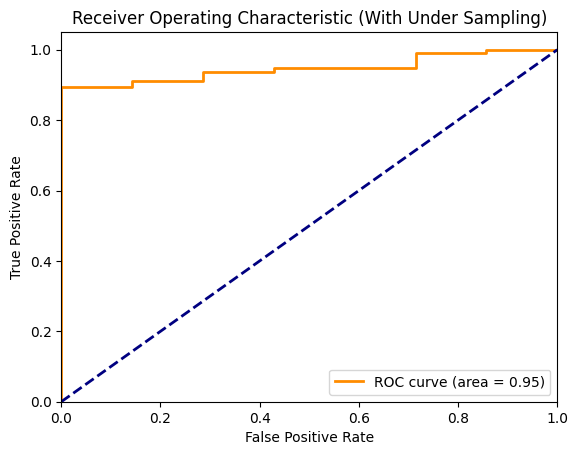

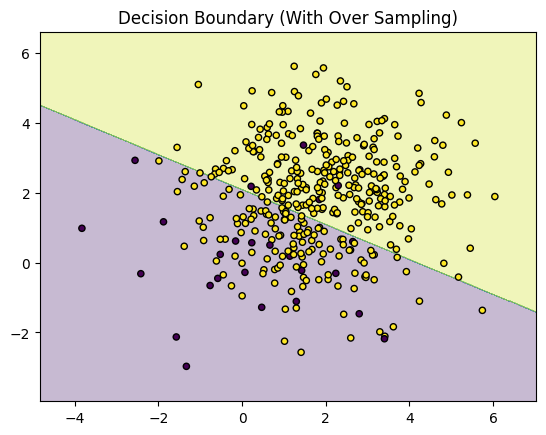

In [7]:
# Plotting ROC AUC Curve for resampled data
fpr_rus, tpr_rus, _ = roc_curve(y_test, y_prob_rus)
plt.figure()
plt.plot(fpr_rus, tpr_rus, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc_score(y_test, y_prob_rus))
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (With Under Sampling)')
plt.legend(loc="lower right")
plt.show()

# Function to plot decision boundaries for resampled data
def plot_decision_boundaries_ros(X, y, model):
    plot_step = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                         np.arange(y_min, y_max, plot_step))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', s=20)
    plt.title("Decision Boundary (With Over Sampling)")
    plt.show()
# Plot decision boundary for resampled data
plot_decision_boundaries_ros(X, y, lr)


In [ ]:
# Even the model is not predicting properly, but model is giving importance to both majority and minority. since dataset is not linear, log reg is not giving much accuracy.


Oversampling effects
Before sampling : 1    262
0     18
Name: count, dtype: int64
After sampling 1    262
0    262
Name: count, dtype: int64


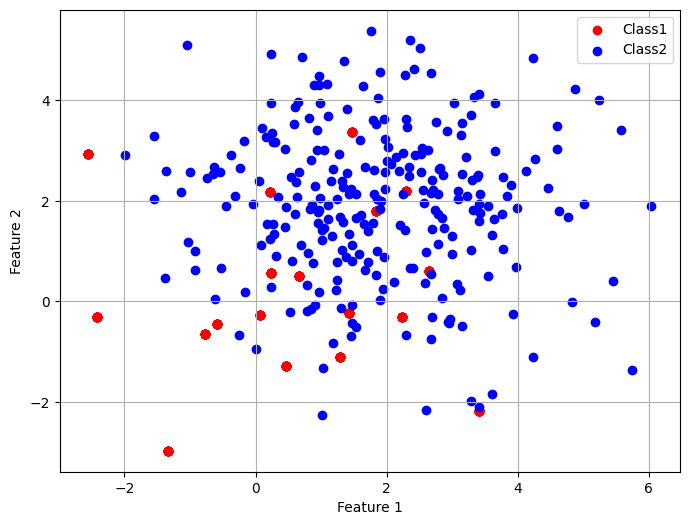

In [12]:
# OverSampler

from imblearn.over_sampling import RandomOverSampler
ros = RandomOverSampler(random_state=42)
X_resampled,y_resampled = ros.fit_resample(X_train,y_train)

print("Oversampling effects")
print(f"Before sampling : {pd.Series(y_train).value_counts()}")
print(f"After sampling",pd.Series(y_resampled).value_counts())
plt.figure(figsize=(8,6))
plt.scatter(X_resampled[y_resampled==0][:,0],X_resampled[y_resampled==0][:,1],color = 'red',label='Class1')
plt.scatter(X_resampled[y_resampled==1][:,0],X_resampled[y_resampled==1][:,1],color = 'blue',label='Class2')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()


In [9]:
# red points may seem not over sampled. but actually it is. the points are overlapped. i.e they are duplicated.

Classification Report (With Over Sampling):
              precision    recall  f1-score   support

           0       0.18      1.00      0.31         7
           1       1.00      0.73      0.84       113

    accuracy                           0.74       120
   macro avg       0.59      0.86      0.58       120
weighted avg       0.95      0.74      0.81       120

ROC AUC Score (With Over Sampling): 0.95448798988622


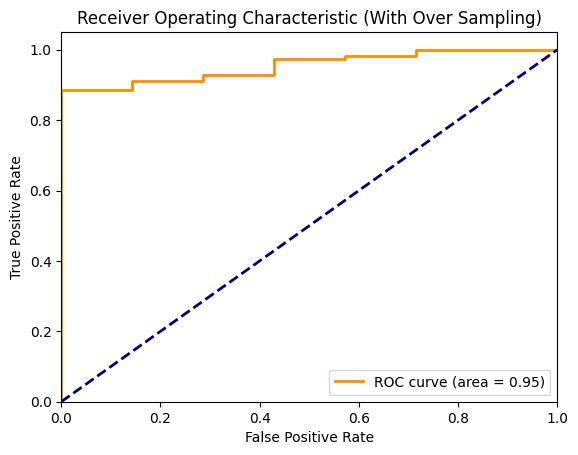

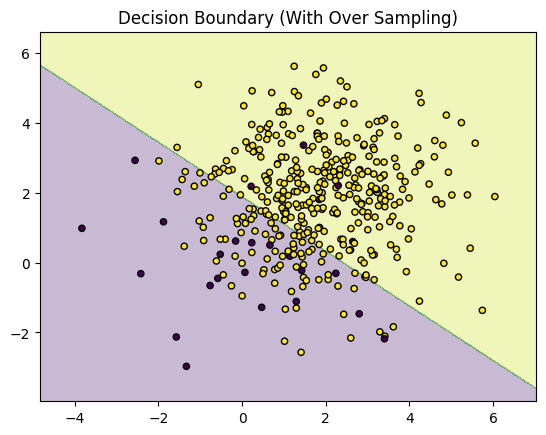

In [11]:
lr.fit(X_resampled, y_resampled)
y_pred_rus = lr.predict(X_test)
y_prob_rus =lr.predict_proba(X_test)[:,1]
# Print classification report for resampled data
print("Classification Report (With Over Sampling):")
print(classification_report(y_test, y_pred_rus))

# Print ROC AUC Score for resampled data
print("ROC AUC Score (With Over Sampling):", roc_auc_score(y_test, y_prob_rus))


# Plotting ROC AUC Curve for resampled data
fpr_rus, tpr_rus, _ = roc_curve(y_test, y_prob_rus)
plt.figure()
plt.plot(fpr_rus, tpr_rus, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc_score(y_test, y_prob_rus))
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (With Over Sampling)')
plt.legend(loc="lower right")
plt.show()

# Function to plot decision boundaries for resampled data
def plot_decision_boundaries_ros(X, y, model):
    plot_step = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                         np.arange(y_min, y_max, plot_step))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', s=20)
    plt.title("Decision Boundary (With Over Sampling)")
    plt.show()
# Plot decision boundary for resampled data
plot_decision_boundaries_ros(X, y, lr)


Oversampling  using SMOTE
Before sampling : 1    262
0     18
Name: count, dtype: int64
After sampling 1    262
0    262
Name: count, dtype: int64


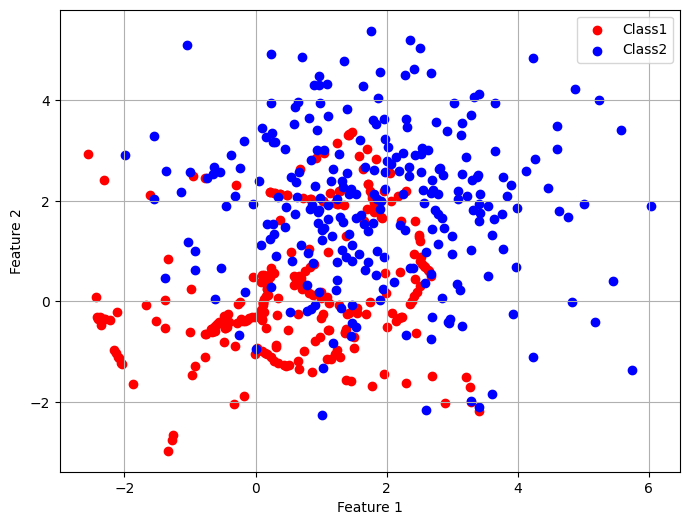

In [13]:
# SMOTE

from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_resampled_smote,y_resampled_smote = smote.fit_resample(X_train,y_train)
print("Oversampling  using SMOTE")
print(f"Before sampling : {pd.Series(y_train).value_counts()}")
print(f"After sampling",pd.Series(y_resampled_smote).value_counts())
plt.figure(figsize=(8,6))
plt.scatter(X_resampled_smote[y_resampled_smote==0][:,0],X_resampled_smote[y_resampled_smote==0][:,1],color = 'red',label='Class1')
plt.scatter(X_resampled_smote[y_resampled_smote==1][:,0],X_resampled_smote[y_resampled_smote==1][:,1],color = 'blue',label='Class2')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()


Classification Report (With SMOTE):
              precision    recall  f1-score   support

           0       0.17      1.00      0.29         7
           1       1.00      0.69      0.82       113

    accuracy                           0.71       120
   macro avg       0.58      0.85      0.55       120
weighted avg       0.95      0.71      0.79       120

ROC AUC Score (With SMOTE): 0.95448798988622


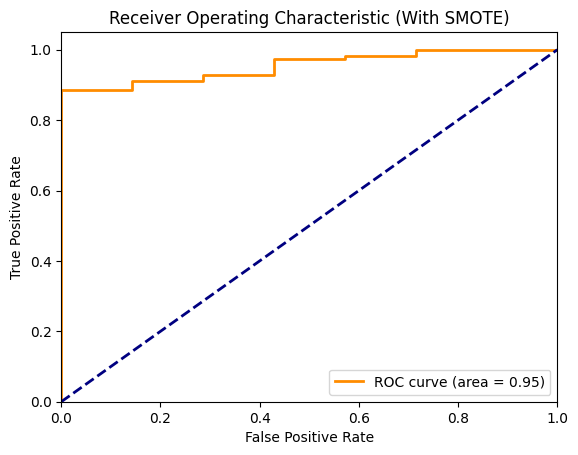

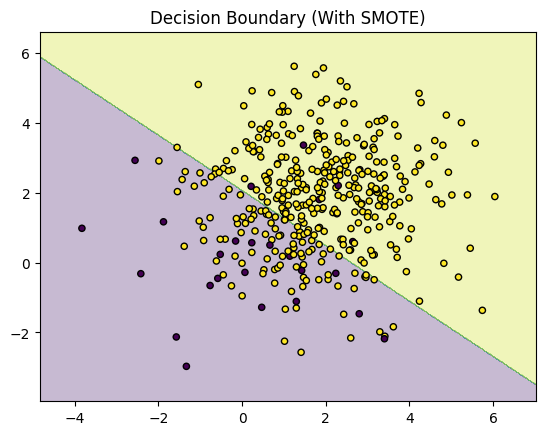

In [14]:
lr.fit(X_resampled_smote, y_resampled_smote)
# Predict test set
y_pred_smote = lr.predict(X_test)
y_proba_smote = lr.predict_proba(X_test)[:, 1]

# Print classification report for SMOTE data
print("Classification Report (With SMOTE):")
print(classification_report(y_test, y_pred_smote))

# Print ROC AUC Score for SMOTE data
print("ROC AUC Score (With SMOTE):", roc_auc_score(y_test, y_proba_smote))

# Plotting ROC AUC Curve for SMOTE data
fpr_smote, tpr_smote, _ = roc_curve(y_test, y_proba_smote)
plt.figure()
plt.plot(fpr_smote, tpr_smote, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc_score(y_test, y_proba_smote))
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (With SMOTE)')
plt.legend(loc="lower right")
plt.show()

# Function to plot decision boundaries for SMOTE data
def plot_decision_boundaries_smote(X, y, model):
    plot_step = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                         np.arange(y_min, y_max, plot_step))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', s=20)
    plt.title("Decision Boundary (With SMOTE)")
    plt.show()

# Plot decision boundary for SMOTE data
plot_decision_boundaries_smote(X, y, lr)

Classification Report (With Ensemble Methods):
              precision    recall  f1-score   support

           0       0.15      0.57      0.24         7
           1       0.97      0.81      0.88       113

    accuracy                           0.79       120
   macro avg       0.56      0.69      0.56       120
weighted avg       0.92      0.79      0.84       120

ROC AUC Score (With SMOTE): 0.8324905183312263


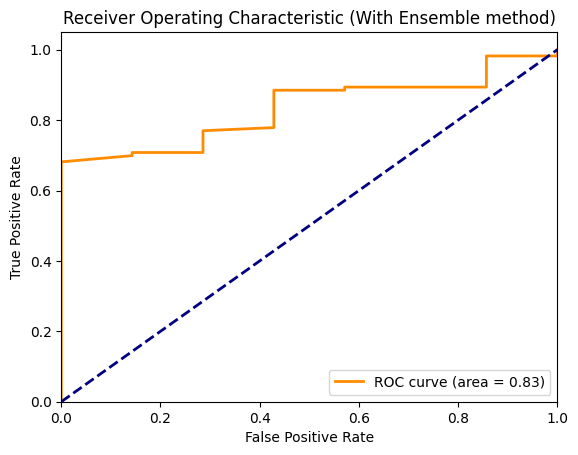

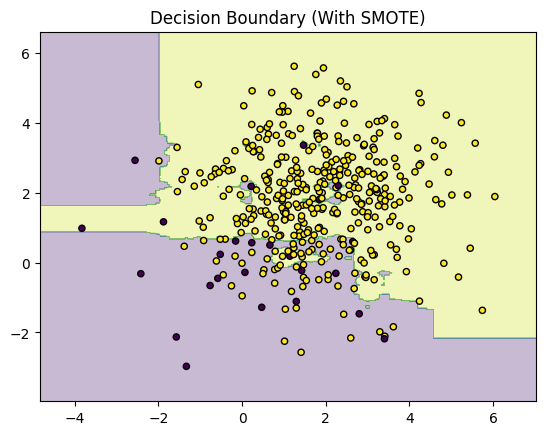

In [4]:
# Using ENsemble Methods

from imblearn.ensemble import BalancedRandomForestClassifier

classifier = BalancedRandomForestClassifier(random_state=42)
classifier.fit(X_train,y_train)

y_pred_ensemble   = classifier.predict(X_test)
y_prob_ensemble = classifier.predict_proba(X_test)[:,1]


# Print classification report for SMOTE data
print("Classification Report (With Ensemble Methods):")
print(classification_report(y_test, y_pred_ensemble))

# Print ROC AUC Score for SMOTE data
print("ROC AUC Score (With SMOTE):", roc_auc_score(y_test, y_prob_ensemble))

# Plotting ROC AUC Curve for SMOTE data
fpr_smote, tpr_smote, _ = roc_curve(y_test, y_prob_ensemble)
plt.figure()
plt.plot(fpr_smote, tpr_smote, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc_score(y_test, y_prob_ensemble))
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (With Ensemble method)')
plt.legend(loc="lower right")
plt.show()

# Function to plot decision boundaries for SMOTE data
def plot_decision_boundaries_smote(X, y, model):
    plot_step = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                         np.arange(y_min, y_max, plot_step))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', s=20)
    plt.title("Decision Boundary (With SMOTE)")
    plt.show()

# Plot decision boundary for SMOTE data
plot_decision_boundaries_smote(X, y, classifier)

In [5]:
# Model is giving importance to minority and majority data points

Classification Report (With Ensemble Methods):
              precision    recall  f1-score   support

           0       0.12      1.00      0.22         7
           1       1.00      0.56      0.72       113

    accuracy                           0.58       120
   macro avg       0.56      0.78      0.47       120
weighted avg       0.95      0.58      0.69       120

ROC AUC Score (With SMOTE): 0.9557522123893806


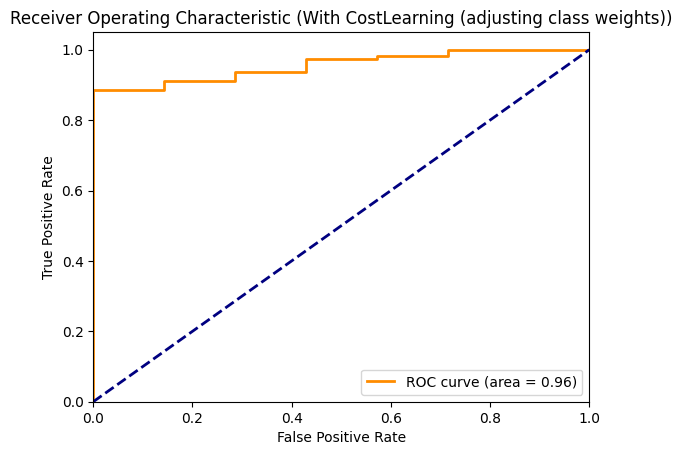

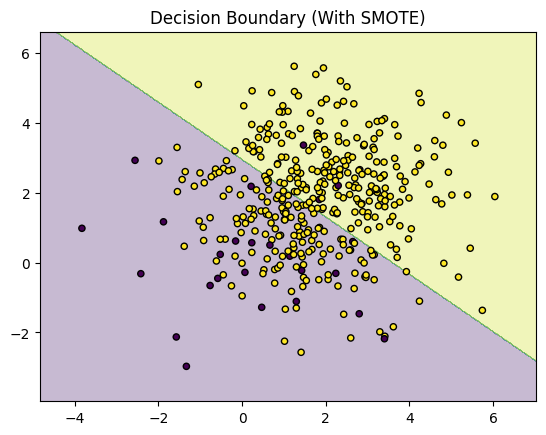

In [8]:
# Cost Sensitive Learning Process( 1. Class Wieghts)

model = LogisticRegression(class_weight={0:25,1:1},solver='liblinear')
model.fit(X_train,y_train)

y_pred_class_weight   = model.predict(X_test)
y_prob_class_weight = model.predict_proba(X_test)[:,1]


# Print classification report for SMOTE data
print("Classification Report (With Ensemble Methods):")
print(classification_report(y_test, y_pred_class_weight))

# Print ROC AUC Score for SMOTE data
print("ROC AUC Score (With SMOTE):", roc_auc_score(y_test, y_prob_class_weight))

# Plotting ROC AUC Curve for SMOTE data
fpr_smote, tpr_smote, _ = roc_curve(y_test, y_prob_class_weight)
plt.figure()
plt.plot(fpr_smote, tpr_smote, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc_score(y_test, y_prob_class_weight))
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (With CostLearning (adjusting class weights))')
plt.legend(loc="lower right")
plt.show()

# Function to plot decision boundaries for SMOTE data
def plot_decision_boundaries_smote(X, y, model):
    plot_step = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                         np.arange(y_min, y_max, plot_step))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', s=20)
    plt.title("Decision Boundary (With SMOTE)")
    plt.show()

# Plot decision boundary for SMOTE data
plot_decision_boundaries_smote(X, y, model)

c:\Users\sathe\anaconda3\envs\ml_env\lib\site-packages\xgboost\core.py:751: UserWarning: [09:22:03] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "silent" } are not used.

  return func(**kwargs)


Classification Report:
              precision    recall  f1-score   support

           0       0.17      0.57      0.27         7
           1       0.97      0.83      0.90       113

    accuracy                           0.82       120
   macro avg       0.57      0.70      0.58       120
weighted avg       0.92      0.82      0.86       120

ROC AUC Score: 0.7319848293299621


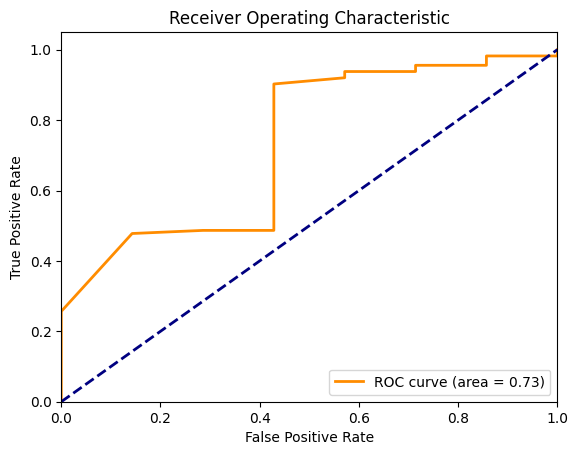

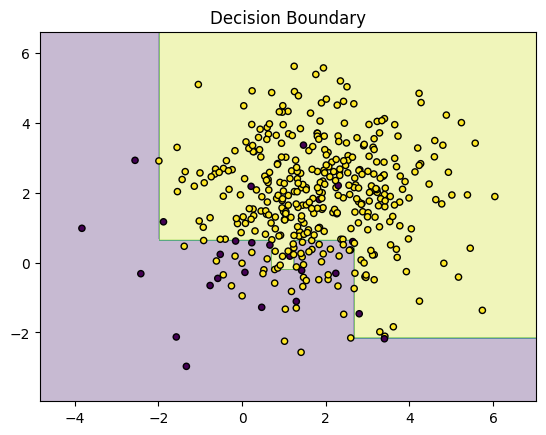

In [10]:
# Cost Sensitive LEarning (Custom Loss Function)
import xgboost as xgb
def custom_loss(preds, dtrain):
    labels = dtrain.get_label()
    preds = 1.0 / (1.0 + np.exp(-preds))  # Convert to probability

    # Define penalties
    false_positive_penalty = 10
    false_negative_penalty = 1.0

    grad = (preds - labels) * ((labels == 1) * false_negative_penalty + (labels == 0) * false_positive_penalty)
    hess = preds * (1 - preds) * ((labels == 1) * false_negative_penalty + (labels == 0) * false_positive_penalty)
    return grad, hess

# Convert to DMatrix object
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

# Set up parameters
params = {
    'max_depth': 3,
    'eta': 0.1,
    'silent': 1,
}

# Train the model
bst = xgb.train(params, dtrain, num_boost_round=10, obj=custom_loss)

# Predict test set
y_pred = np.where(bst.predict(dtest) > 0.5, 1, 0)
y_proba = bst.predict(dtest)  # Probability predictions

# Print classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Print ROC AUC Score
auc_score = roc_auc_score(y_test, y_proba)
print("ROC AUC Score:", auc_score)

# Plotting ROC AUC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % auc_score)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

def plot_decision_boundaries(X, y, model):
    plot_step = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                         np.arange(y_min, y_max, plot_step))
    Z = model.predict(xgb.DMatrix(np.c_[xx.ravel(), yy.ravel()]))
    Z = np.where(Z > 0.5, 1, 0).reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', s=20)
    plt.title("Decision Boundary")
    plt.show()

# Plot decision boundary
plot_decision_boundaries(X, y, bst)